# Project 2: Can you hear the size of a reservoir?

# Introduction
## Part 1
TO DO

## Part 2
TO DO

## Solver class

In [37]:
import numpy as np
import matplotlib.pyplot as plt

class PressureSolver:
    """
    A finite difference solver to solve pressure distribution in
    a reservoir, logarithmic grid has been used, y = ln(r/rw)
    The solver uses SI units internally, while "practical field units"
    are required as input.

    Input arguments:

    name                                symbol  unit
    -----------------------------------------------------------------
    Number of grid points               N       dimensionless
    Constant time step                  dt      days
    Well radius                         rw      ft
    Outer reservoir boundary            re      ft
    Height of reservoir                 h       ft
    Absolute permeability               k       mD
    Porosity                            phi     dimensionless
    Fluid viscosity                     mu      mPas (cP)
    Total (rock+fluid) compressibility  ct      1 / psi
    Constant flow rate at well          Q       bbl / day
    Initial reservoir pressure          pi      psi
    -----------------------------------------------------------------

    Solving parameters:

    name                type            description
    -----------------------------------------------------------------
    lazy                Bool            True: lazy BC                                
    alpha_simple        Bool            True: set alpha to 1.0
    -----------------------------------------------------------------
    """
    def __init__(self,
    N,
    dt=1.0,
    rw=0.318,
    re=1000.0,
    h=11.0,
    phi=0.25,
    mu=1.0,
    ct=7.8e-6,
    Q=1000.0,
    k=500,
    pi=4100.0,
    lazy=False,
    alpha_simple=False):
        # Unit conversion factors (input units --> SI)
        self.ft_to_m = 0.3048
        self.psi_to_pa = 6894.75729
        self.day_to_sec = 24.*60.*60.
        self.bbl_to_m3 = 0.1589873
        # Grid
        self.N = N
        self.rw = rw*self.ft_to_m
        self.re = re*self.ft_to_m
        self.h = h*self.ft_to_m
        # define ye, dy, y, and r
        self.ye = np.log(self.re / self.rw) # Equation 12 in the project
        self.dy = self.ye / self.N # step size in y
        self.y = np.arange(self.dy/2, self.ye, self.dy) # y at nodes, see Figure 5
        self.r = self.rw * np.exp(self.y) # Equation 16 in the project
        # Rock and fluid properties
        self.k = k*1e-15 / 1.01325 # from Darcy to m^2
        self.phi = phi
        self.mu = mu*1e-3 # from cP to Pas
        self.ct = ct / self.psi_to_pa
        # Initial and boundary conditions
        self.Q = Q*self.bbl_to_m3 / self.day_to_sec
        self.pi = pi*self.psi_to_pa
        # Time control for simulation
        self.dt = dt*self.day_to_sec
        
        # TO DO: Add more stuff below here....
        self.eta = self.k / (self.mu * self.phi * self.ct)
        
        # lazy and alpha_simple
        self.lazy = lazy
        if alpha_simple:
            self.alpha = 1.0
        else:
            self.alpha = (self.Q * self.mu) / (2 * np.pi * self.k * self.h) 

        # Solver variables
        self.A = np.zeros((N, N))
        self.rhs = np.zeros((N))
        self.p = np.array([])

    # ------------------------------
    # Steady state solver
    # ------------------------------
    def setup_matrix_steady_state(self):
        """ 
        Constructs the A matrix for steady state
        """
        N = self.N

        # Inner boundary
        self.A[0, 0] = -1
        self.A[0, 1] = 1

        # Interior nodes
        for i in range(1, N - 1):
            self.A[i, i - 1] = 1
            self.A[i, i] = -2
            self.A[i, i + 1] = 1

        # Outer boundary
        self.A[N - 1, N - 2] = 1
        if self.lazy:
            self.A[N - 1, N - 1] = -2
        else:
            self.A[N - 1, N - 1] = -3

        return self.A
    

    def setup_rhs_steady_state(self):
        """ 
        Constructs the right hand side vector for 
        steady state
        """
        N = self.N
        self.rhs[0] = self.alpha * self.dy

        if self.lazy:
            self.rhs[N-1] = -self.pi
        else:
            self.rhs[N-1] = -2 * self.pi

        return self.rhs
            

    def solve_steady_state(self):
        """ 
        Solves for steady state pressures 
        """
        self.setup_matrix_steady_state()
        self.setup_rhs_steady_state()

        self.p = np.linalg.solve(self.A, self.rhs)
        return self.p


    def analytical_steady_state(self):
        """ 
        Analytical solution for steady state
        """
        self.p_analytical = self.pi + self.alpha * (self.y - self.ye)
        return self.p_analytical

    def plot_steady_state(self):
        """ 
        Solves and plots the steady state pressures, 
        both numerical and analytical
        """
        #
        self.solve_steady_state()
        self.analytical_steady_state()

        plt.figure()
        plt.scatter(self.y, self.p, label="numerical")
        plt.scatter(self.y, self.p_analytical, label="analytical", s=12)
        plt.legend()


    # --------------------------------------
    # Time dependent solution
    # --------------------------------------

        
         

## Exercise 1: part 5

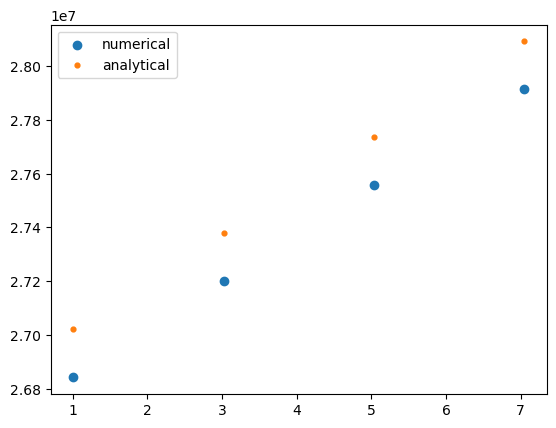

In [38]:
# Test your steady state solution here, lazy first
solver = PressureSolver(N=4, lazy=True)
solver.plot_steady_state()

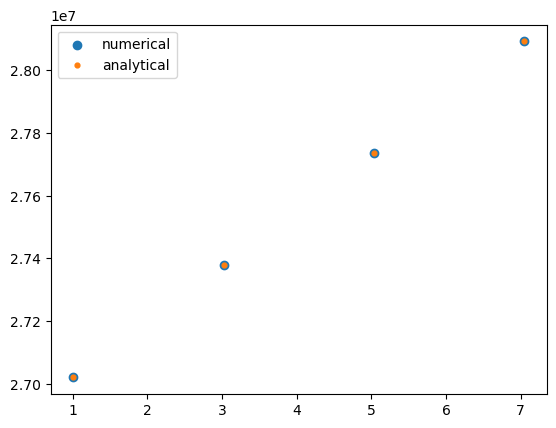

In [39]:
# Test your steady state solution here, not lazy second
solver = PressureSolver(N=4, lazy=False)
solver.plot_steady_state()

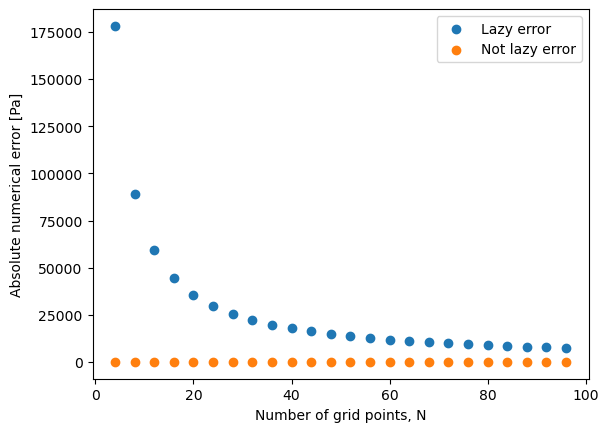

[np.float64(178196.94650751352), np.float64(89098.47325376421), np.float64(59398.98216916993), np.float64(44549.23662687093), np.float64(35639.389301501215), np.float64(29699.491084605455), np.float64(25456.706643950194), np.float64(22274.61831343174), np.float64(19799.660723034292), np.float64(17819.69465078786), np.float64(16199.722409751266), np.float64(14849.745542313904), np.float64(13707.457423668355), np.float64(12728.35332198441), np.float64(11879.796433832496), np.float64(11137.309156712145), np.float64(10482.173324014992), np.float64(9899.830361504108), np.float64(9378.786658324301), np.float64(8909.847325336188), np.float64(8485.568881329149), np.float64(8099.861204862595), np.float64(7747.693326406181), np.float64(7424.872771076858)]
[np.float64(0.0), np.float64(3.725290298461914e-09), np.float64(0.0), np.float64(7.450580596923828e-09), np.float64(0.0), np.float64(1.862645149230957e-08), np.float64(1.862645149230957e-08), np.float64(7.450580596923828e-09), np.float64(2.2351

In [47]:
# Make a scatter plot of the numerical error versus grid size 
# for the lazy and not lazy implementation.
# Use the analytical formula as the true solution

# y - numerical error
# x - grid size
grid_points = np.arange(4, 100, 4)
error_lazy = []
error_not_lazy = []

for n in grid_points:
    solver_lazy = PressureSolver(N=n, lazy=True)
    p = solver_lazy.solve_steady_state()
    p_analytical = solver_lazy.analytical_steady_state()
    error_lazy.append(np.abs(p[n//2] - p_analytical[n//2]))

    solver_better = PressureSolver(N=n, lazy=False)
    p_b = solver_better.solve_steady_state()
    p_analytical_b = solver_better.analytical_steady_state()
    error_not_lazy.append(np.abs(p_b[n//2] - p_analytical_b[n//2]))

plt.figure()
plt.scatter(grid_points, error_lazy, label="Lazy error")
plt.scatter(grid_points, error_not_lazy, label="Not lazy error")
plt.xlabel("Number of grid points, N")
plt.ylabel("Absolute numerical error [Pa]")
plt.legend()
plt.show()

print(error_lazy)
print(error_not_lazy)

Does the error scale as you expect? Discuss